We do the initial setup and loading. We need both the validation set (to find the optimal thresholds) and the test set (for the final unbiased evaluation).

In [1]:
import os
import time
import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score
from transformers import AutoTokenizer

# Import modularized architectures
import sys
sys.path.append('..')
from models.lstm import BiLSTMClassifier
from models.transformers import UniversalTransformerClassifier

# Re-import dataset classes (ensure these match Notebook 2)
from src.data_utils import Vocabulary, LSTMDataset, BertDataset # Assuming you moved classes to a utils file, or paste them here

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PROCESSED_DIR = '../data/processed'
MODELS_DIR = '../models/saved_weights'
RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"✅ Evaluating on device: {DEVICE}")

# Load validation and test data
val_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'val.csv'))
test_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'test.csv'))

LABEL_COLS = [c for c in val_df.columns if c not in ['Argument ID', 'text_raw', 'text_clean']]
y_val = val_df[LABEL_COLS].values
y_test = test_df[LABEL_COLS].values

✅ Evaluating on device: cuda


We create one function to get the raw logit predictions from a model and another to get the threshold that optimizes the F1-score

In [2]:
def get_predictions(model, loader, is_bert=False):
    """Runs inference and returns raw probabilities and inference time."""
    model.eval()
    all_probs = []
    
    start_time = time.time()
    with torch.no_grad():
        for batch in loader:
            if is_bert:
                input_ids = batch['input_ids'].to(DEVICE)
                mask = batch['attention_mask'].to(DEVICE)
                outputs = model(input_ids, mask)
            else:
                inputs = batch[0].to(DEVICE)
                outputs = model(inputs)
            
            # Convert logits to probabilities
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.extend(probs)
            
    inference_time = time.time() - start_time
    return np.array(all_probs), inference_time

def optimize_thresholds(y_true, y_probs):
    """Finds the best threshold (between 0.1 and 0.9) for each of the 20 classes."""
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_thresholds = []
    
    for class_idx in range(y_true.shape[1]):
        best_f1 = 0
        best_t = 0.5
        for t in thresholds:
            preds = (y_probs[:, class_idx] > t).astype(int)
            f1 = f1_score(y_true[:, class_idx], preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
        best_thresholds.append(best_t)
        
    return np.array(best_thresholds)

We instantiate the tokenizers and loaders needed for each architecture.

In [3]:
# 1. LSTM Setup
vocab = Vocabulary(pd.read_csv(os.path.join(PROCESSED_DIR, 'train.csv'))['text_clean'].values)
val_loader_lstm = DataLoader(LSTMDataset(val_df['text_clean'].values, y_val, vocab), batch_size=64)
test_loader_lstm = DataLoader(LSTMDataset(test_df['text_clean'].values, y_test, vocab), batch_size=64)

# 2. Transformer Loaders (we'll generate these dynamically in the execution cell to save memory)
def get_transformer_loaders(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    val_loader = DataLoader(BertDataset(val_df['text_raw'].values, y_val, tokenizer), batch_size=16)
    test_loader = DataLoader(BertDataset(test_df['text_raw'].values, y_test, tokenizer), batch_size=16)
    return val_loader, test_loader

We evaluate all trained models, optimize the threshold using the validation set, forecast the test set and display the results

In [4]:
import gc

models_to_evaluate = [
    {'name': 'BiLSTM', 'is_bert': False, 'file': 'bilstm_best.pt', 'loader_name': None},
    {'name': 'DistilBERT', 'is_bert': True, 'file': 'distilbert_best.pt', 'loader_name': 'distilbert-base-uncased'},
    {'name': 'BERT', 'is_bert': True, 'file': 'bert_best.pt', 'loader_name': 'bert-base-uncased'},
    {'name': 'RoBERTa', 'is_bert': True, 'file': 'roberta_best.pt', 'loader_name': 'roberta-base'},
]

results = []

for m_info in models_to_evaluate:
    model_path = os.path.join(MODELS_DIR, m_info['file'])
    if not os.path.exists(model_path):
        print(f"⚠️ Skipping {m_info['name']} (weights not found)")
        continue
        
    print(f"--- Evaluating {m_info['name']} ---")
    
    # Instantiate Model
    if m_info['is_bert']:
        model = UniversalTransformerClassifier(model_name=m_info['loader_name']).to(DEVICE)
        val_loader, test_loader = get_transformer_loaders(m_info['loader_name'])
    else:
        model = BiLSTMClassifier(vocab_size=len(vocab.vocab)).to(DEVICE)
        val_loader, test_loader = val_loader_lstm, test_loader_lstm
        
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    # 1. Get Val Probs and Optimize Thresholds
    val_probs, _ = get_predictions(model, val_loader, is_bert=m_info['is_bert'])
    optimal_thresholds = optimize_thresholds(y_val, val_probs)
    
    # -> NEW: Print the discovered thresholds
    print(f"   Mean Optimal Threshold: {optimal_thresholds.mean():.2f}")
    print(f"   Thresholds array: {np.round(optimal_thresholds, 2)}")
    
    # 2. Get Test Probs and measure Inference Time
    test_probs, inf_time = get_predictions(model, test_loader, is_bert=m_info['is_bert'])
    
    # 3. Apply thresholds and calculate final F1
    test_preds = (test_probs > optimal_thresholds).astype(int)
    final_f1 = f1_score(y_test, test_preds, average='macro', zero_division=0)
    
    print(f"✅ {m_info['name']} Test F1-Macro: {final_f1:.4f} (Inference time: {inf_time:.2f}s)\n")
    
    results.append({
        'Model': m_info['name'],
        'F1-Macro': final_f1,
        'Parameters': params,
        'Inference Time (s)': inf_time,
        'ms/sample': (inf_time / len(y_test)) * 1000
    })
    
    # Cleanup memory
    del model
    gc.collect()
    torch.cuda.empty_cache()

--- Evaluating BiLSTM ---
   Mean Optimal Threshold: 0.46
   Thresholds array: [0.35 0.25 0.5  0.25 0.5  0.3  0.45 0.45 0.35 0.35 0.5  0.5  0.55 0.7
 0.45 0.4  0.5  0.7  0.55 0.5 ]
✅ BiLSTM Test F1-Macro: 0.4913 (Inference time: 0.09s)

--- Evaluating DistilBERT ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Mean Optimal Threshold: 0.44
   Thresholds array: [0.45 0.35 0.55 0.65 0.4  0.25 0.4  0.35 0.4  0.4  0.45 0.6  0.6  0.55
 0.45 0.3  0.35 0.6  0.3  0.45]
✅ DistilBERT Test F1-Macro: 0.5349 (Inference time: 0.66s)

--- Evaluating BERT ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Mean Optimal Threshold: 0.51
   Thresholds array: [0.55 0.4  0.65 0.45 0.5  0.65 0.4  0.55 0.5  0.35 0.6  0.6  0.7  0.4
 0.5  0.35 0.45 0.6  0.5  0.4 ]
✅ BERT Test F1-Macro: 0.5293 (Inference time: 1.02s)

--- Evaluating RoBERTa ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Mean Optimal Threshold: 0.49
   Thresholds array: [0.55 0.4  0.3  0.45 0.55 0.45 0.55 0.55 0.35 0.55 0.75 0.35 0.65 0.4
 0.4  0.3  0.55 0.7  0.45 0.6 ]
✅ RoBERTa Test F1-Macro: 0.5414 (Inference time: 0.98s)



We compare the results we obtain against the baseline benchmark from assignment 1, creating visual plots as the raw table can be hard to read


=== FINAL ARCHITECTURE COMPARISON ===
            Model  F1-Macro  Parameters  Inference Time (s)  ms/sample
Baseline (LogReg)  0.508100      600020            0.053900   0.034000
           BiLSTM  0.491285     3440788            0.092733   0.103844
       DistilBERT  0.534917    66378260            0.658725   0.737654
             BERT  0.529317   109497620            1.021308   1.143682
          RoBERTa  0.541358   124661012            0.976149   1.093112

Saved table to ../results/architecture_comparison.csv


/tmp/ipykernel_793881/2280366124.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='F1-Macro', palette=colors, ax=axes[0])
/tmp/ipykernel_793881/2280366124.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='Parameters', palette=colors, ax=axes[1])
/tmp/ipykernel_793881/2280366124.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='ms/sample', palette=colors, ax=axes[2])


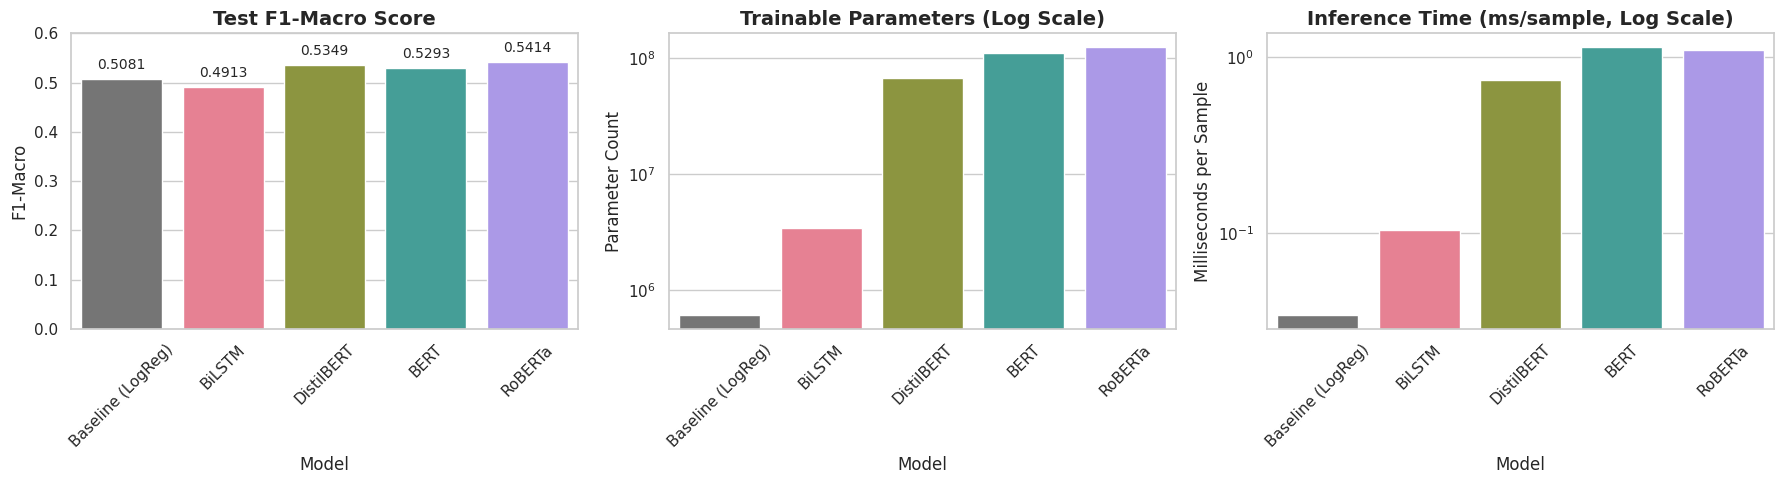

Saved visual comparisons to ../results/architecture_comparison_plots.png


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define Baseline Data
baseline_data = {
    'Model': 'Baseline (LogReg)',
    'F1-Macro': 0.5081, # The score we are trying to beat
    'Parameters': 600020, 
    'Inference Time (s)': 0.0539, 
    'ms/sample': 0.034
}

# 2. Build the DataFrame
results_df = pd.DataFrame([baseline_data] + results)
print("\n=== FINAL ARCHITECTURE COMPARISON ===")
print(results_df.to_string(index=False))

# Export for the LaTeX report
results_df.to_csv(os.path.join(RESULTS_DIR, 'architecture_comparison.csv'), index=False)
print(f"\nSaved table to {RESULTS_DIR}/architecture_comparison.csv")

# 3. Visual Comparisons
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Use a distinct color palette
colors = ['#757575'] + sns.color_palette("husl", len(results_df) - 1)

# --- Plot A: F1-Macro ---
sns.barplot(data=results_df, x='Model', y='F1-Macro', palette=colors, ax=axes[0])
axes[0].set_title('Test F1-Macro Score', fontsize=14, fontweight='bold')
axes[0].set_ylabel('F1-Macro')
axes[0].set_ylim(0, 0.6)
# Add text labels on top of bars
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.4f}", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, xytext=(0, 5), 
                     textcoords='offset points')

# --- Plot B: Parameters (Log Scale) ---
sns.barplot(data=results_df, x='Model', y='Parameters', palette=colors, ax=axes[1])
axes[1].set_title('Trainable Parameters (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Parameter Count')
axes[1].set_yscale('log')

# --- Plot C: Inference Time (Log Scale) ---
sns.barplot(data=results_df, x='Model', y='ms/sample', palette=colors, ax=axes[2])
axes[2].set_title('Inference Time (ms/sample, Log Scale)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Milliseconds per Sample')
axes[2].set_yscale('log')

# Formatting
for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

# Save the plot for the LaTeX report
plot_path = os.path.join(RESULTS_DIR, 'architecture_comparison_plots.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved visual comparisons to {plot_path}")

- BiLSTM model had the worst performance. This can be due to the lack of pretraining compared to the transformer models we used.
- All transformer models surpassed the statistical baseline (CountVec + LogReg)
- Transformer models did not necessarily benefit from increasing complexity and parameters. The lighter DistillBERT obtained a better performance than standard BERT. However, RoBERTa was the best performing models. Since the increase in complexity is not that much, we will keep it as our best model.